In [1]:
from qiskit import QuantumCircuit

## Draw a quantum circuit

In [2]:
# Build a quantum circuit
circuit = QuantumCircuit(3, 3)
circuit.x(1)
circuit.h(range(3))
circuit.cx(0, 1)
circuit.measure(range(3), range(3));

In [3]:
print(circuit)

     ┌───┐          ┌─┐   
q_0: ┤ H ├───────■──┤M├───
     ├───┤┌───┐┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ H ├┤ X ├─╫─┤M├
     ├───┤└┬─┬┘└───┘ ║ └╥┘
q_2: ┤ H ├─┤M├───────╫──╫─
     └───┘ └╥┘       ║  ║ 
c: 3/═══════╩════════╩══╩═
            2        0  1 


In [12]:
circuit.draw()

┌───┐          ┌─┐   
q_0: ┤ H ├───────■──┤M├───
     ├───┤┌───┐┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├┤ H ├┤ X ├─╫─┤M├
     ├───┤└┬─┬┘└───┘ ║ └╥┘
q_2: ┤ H ├─┤M├───────╫──╫─
     └───┘ └╥┘       ║  ║ 
c: 3/═══════╩════════╩══╩═
            2        0  1

### Alternative renders

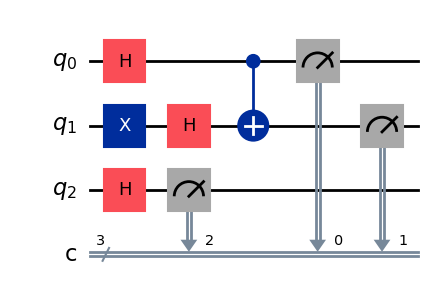

In [6]:
circuit.draw(output = 'mpl')

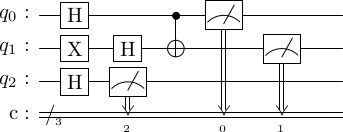

In [7]:
circuit.draw(output='latex')

### Save output

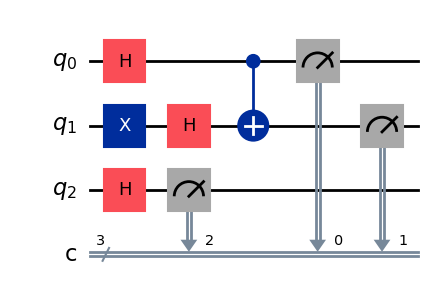

In [8]:
circuit.draw(output='mpl', filename='circ_mpl.jpeg')

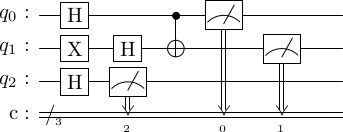

In [9]:
circuit.draw(output='latex', filename='circ_latex.pdf')

### Customize the output

#### Disable plot barriers and reverse bit order

In [10]:
from qiskit import QuantumRegister, ClassicalRegister

# Draw a new circuit with barriers and more registers
q_a = QuantumRegister(3, name="a")
q_b = QuantumRegister(5, name="b")
c_a = ClassicalRegister(3)
c_b = ClassicalRegister(5)

circuit = QuantumCircuit(q_a, q_b, c_a, c_b)
circuit.x(q_a[1])
circuit.x(q_b[1])
circuit.x(q_b[2])
circuit.x(q_b[4])
circuit.barrier()
circuit.h(q_a)
circuit.barrier(q_a)
circuit.h(q_b)
circuit.cswap(q_b[0], q_b[1], q_b[2])
circuit.cswap(q_b[2], q_b[3], q_b[4])
circuit.cswap(q_b[3], q_b[4], q_b[0])
circuit.barrier(q_b)
circuit.measure(q_a, c_a)
circuit.measure(q_b, c_b);

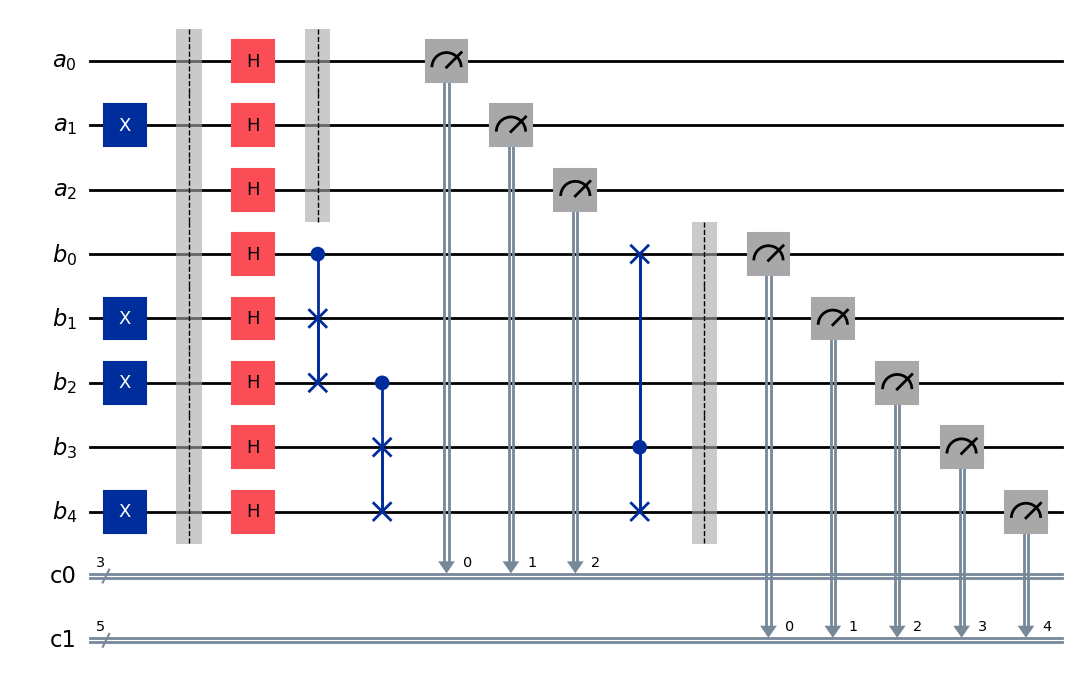

In [11]:
circuit.draw(output= 'mpl')

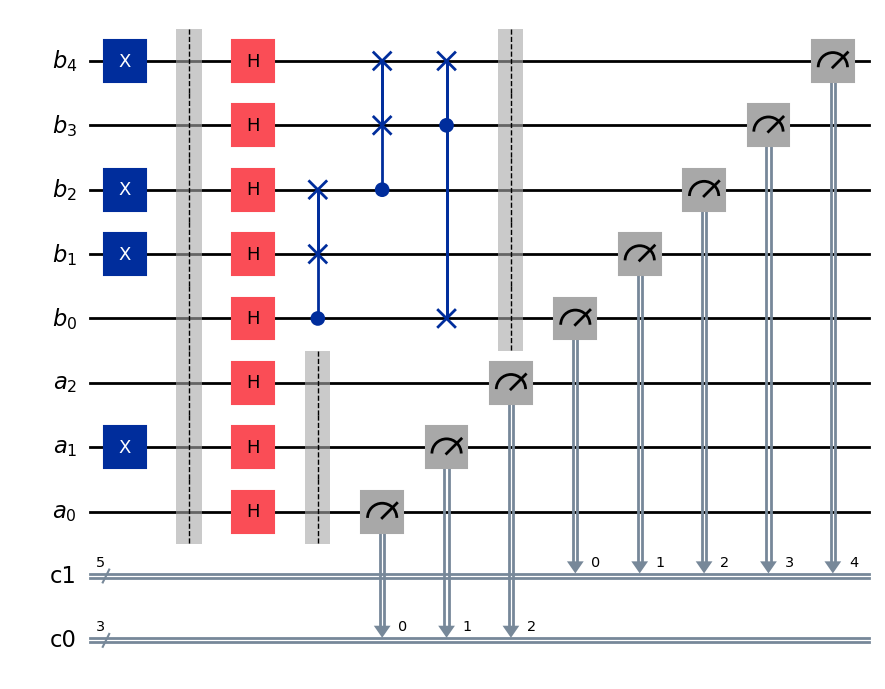

In [12]:
circuit.draw(output = 'mpl', reverse_bits = 'True')

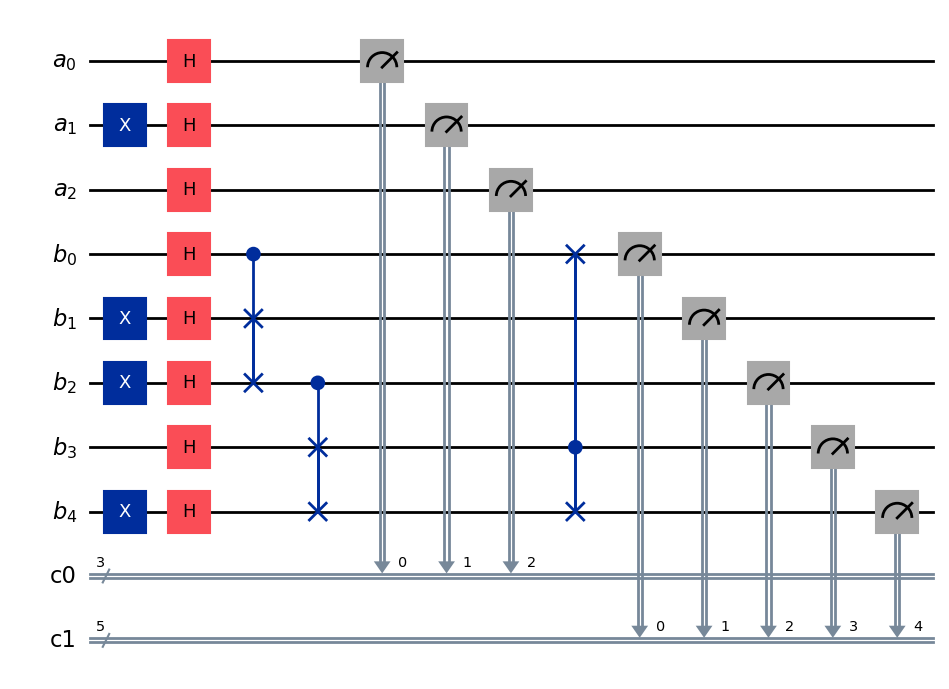

In [13]:
circuit.draw(output='mpl', plot_barriers = False)

#### Render-specific customizations

**fold** sets maximum width for the output. If 'text' render then it sets the maximum number of characters per line. If 'mpl' render it sets the maximum number of layers before folding to next line.

In [14]:
circuit = QuantumCircuit(1)
for _ in range(10):
    circuit.h(0)
# limit line length to 40 characters
circuit.draw(output="text", fold=40)

┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐┌───┐»
q: ┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├┤ H ├»
   └───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«   ┌───┐┌───┐┌───┐
«q: ┤ H ├┤ H ├┤ H ├
«   └───┘└───┘└───┘

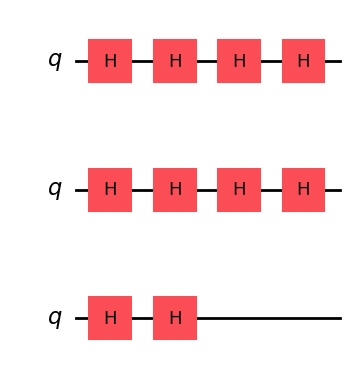

In [15]:
# limit layers to 4 per line
circuit.draw(output="mpl", fold=4)

**style** changes colors and outlines in 'mpl' render.

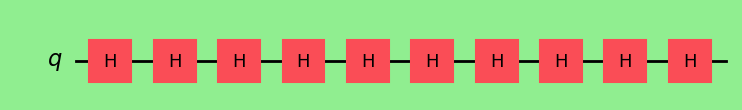

In [16]:
# Change the background color in mpl

style = {"backgroundcolor": "lightgreen"}
circuit.draw(output="mpl", style=style)

**scale** just scales the output of the 'mpl' and 'latex' renders.

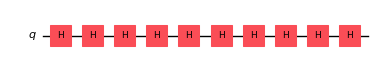

In [17]:
# Scale the mpl output to 1/2 the normal size
circuit.draw(output="mpl", scale=0.5)

#### Rest of options (not included in this doc)

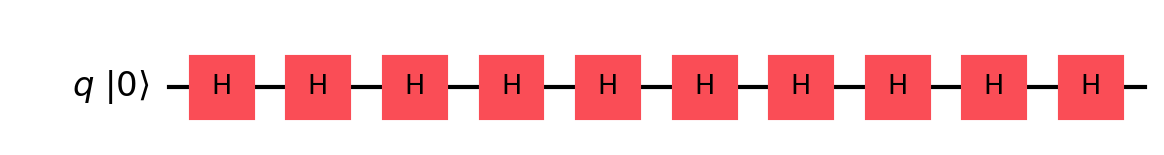

In [18]:
circuit.draw(output='mpl', scale=1.5, filename=None, style=None, interactive=False, plot_barriers=True, reverse_bits=None, justify=None, vertical_compression='medium', idle_wires=None, with_layout=True, fold=None, ax=None, initial_state=True, cregbundle=None, wire_order=None, expr_len=30, measure_arrows=None, barrier_label_len=16)

justify (str | None) – Options are "left", "right" or "none" (str). If anything else is supplied, left justified will be used instead. It refers to where gates should be placed in the output circuit if there is an option. none results in each gate being placed in its own column. Defaults to left

vertical_compression (str | None) – high, medium or low. It merges the lines generated by the text output so the drawing will take less vertical room. Default is medium. Only used by the text output, will be silently ignored otherwise.

idle_wires (bool |str | None) – Include (or not) idle wires (wires with no circuit elements) in output visualization. The string "auto" is also possible, in which case idle wires are shown except when the circuit has a layout attached. Default is "auto" unless the user config file (usually ~/.qiskit/settings.conf) has an alternative value set. For example, circuit_idle_wires = False.

with_layout (bool) – Include layout information, with labels on the physical layout. Default is True.

ax (Any | None) – Only used by the mpl backend. An optional matplotlib.axes.Axes object to be used for the visualization output. If none is specified, a new matplotlib Figure will be created and used. Additionally, if specified there will be no returned Figure since it is redundant.

initial_state (bool) – Adds ∣0⟩ in the beginning of the qubit wires and
0 to classical wires. Default is False.

cregbundle (bool | None) – If set to True, bundle classical registers. Default is True, except for when output is set to "text"

wire_order (list[int] | None) – A list of integers used to reorder the display of the bits. The list must have an entry for every bit with the bits in the range 0 to (num_qubits + num_clbits).

expr_len (int) – The number of characters to display if an Expr is used for the condition in a ControlFlowOp. If this number is exceeded, the string will be truncated at that number and ‘…’ added to the end.

measure_arrows (bool | None) – If True, draw an arrow from each measure box down to the classical bit or register where the measure value is placed. If False, do not draw arrow, but instead place the name of the bit or register in the measure box. Default is True unless the user config file (usually ~/.qiskit/settings.conf) has an alternative value set. For example, circuit_measure_arrows = False.



#### Standalone circuit-drawing function

If you have an application where you prefer to draw a circuit with a self-contained function instead of as a method of a circuit object, you can directly use the circuit_drawer() function, which is part of the public stable interface from qiskit.visualization. The function behaves identically to the circuit.draw() method, except that it takes in a circuit object as a required argument.

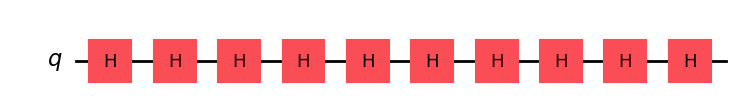

In [19]:
from qiskit.visualization import circuit_drawer

circuit_drawer(circuit, output="mpl", plot_barriers=False)